# Building info dataset preparation

This a helper notebook that is used to prepare the building info. It combines these datasets:

- Addresses
- Traffic/airport/railway noise
- Heating score

In [22]:
import pandas as pd
import geopandas as gpd
import numpy as np

import matplotlib.pyplot as plt
import contextily as cx

In [23]:
addresses = pd.read_csv('./data/address_data.csv')

In [24]:
addresses['street'] = addresses['street'].replace('Stepono Batoro', 'S. Batoro', regex=True)

addresses['fullAddress'] = addresses['fullAddress'].replace('Stepono Batoro', 'S. Batoro', regex=True)

Only a single address was incorrect in the Vilnius Municipality address dataset.

In [25]:
addresses

,gatId,gatIdGr,street,houseNo,eldership,place,longitude,latitude,fullAddress
0,48353,2057,Raisteniškių g.,10A,Pašilaičiai,Vilnius,25.18642,54.74839,Raisteniškių g. 10A
1,22063,211,K. Vanagėlio g.,13,Senamiestis,Vilnius,25.29474,54.67324,K. Vanagėlio g. 13
2,22353,513,Srovės g.,6A,Rasos,Vilnius,25.31733,54.68223,Srovės g. 6A
3,244310,3168,Vaišelgos g.,52A,Verkiai,Vilnius,25.29139,54.77895,Vaišelgos g. 52A
4,273320,3347,Ganyklų g.,16,Paneriai,Vilnius,25.14241,54.61516,Ganyklų g. 16
...,...,...,...,...,...,...,...,...,...
81416,22310,469,Rygos g.,18,Justiniškės,Vilnius,25.21840,54.71639,Rygos g. 18
81417,22485,653,Šeškinės g.,21,Šeškinė,Vilnius,25.25391,54.71374,Šeškinės g. 21
81418,21965,109,Dūkštų g.,26,Šeškinė,Vilnius,25.24440,54.71119,Dūkštų g. 26
81419,66991,2727,Barčių g.,55,Naujininkai,Vilnius,25.25899,54.59667,Barčių g. 55


Addresses that are located in Grigiškės in the heating score dataset have ' (Grigiškės)' appended. We will create a separate column and add the appended text so that the two tables could be joined properly.

In [26]:
addresses['fullAddressGrigiskes'] = np.where(addresses['eldership'] == 'Grigiškės',
                                             addresses['street'].replace(r'\(Grigiškės\)', '', regex=True) + addresses['houseNo'] + ' (Grigiškės)',
                                             addresses['fullAddress'])

In [27]:
traffic_noise = gpd.read_file('./data/traffic_noise.geojson')
railway_noise = gpd.read_file('./data/railway_noise.geojson')
airport_noise = gpd.read_file('./data/airport_noise.geojson')

heating_score = gpd.read_file('./data/heating_score.geojson')

There are 3 rows with missing address values.

In [28]:
heating_score = heating_score.dropna(subset='ADRESAS')

Addresses in the heating score dataset do not match standard notation. The names of people after which the streets were named are written in full and should be shortened.

In [29]:
replacements = {
    'Karlo Gustavo Emilio': 'K. G. E.',
    'Algimanto Petro': 'A. P.',
    'Apolinaro Juozo': 'A. J.',
    'Broniaus Kazio': 'B. K.',
    'Pranciškaus': 'P.',
    'Virginijaus': 'V.',
    'Stanislovo': 'S.',
    r'Jakšto A\.': 'A. Jakšto',
    r'Tumėno A\.': 'A. Tumėno',
    'Kazimiero': 'K.',
    'Žygimanto': 'Ž.',
    'Jeronimo': 'J.',
    'Liongino': 'L.',
    'Liudviko': 'L.',
    'Pauliaus': 'P.',
    'Rolando': 'R.',
    'Stepono': 'S.',
    'Vytauto': 'V.',
    'Eduardo': 'E.',
    'Dariaus': 'D.',
    'Juliaus': 'J.',
    'Loretos': 'L.',
    'Antano': 'A.',
    'Jurgio': 'J.',
    'Mykolo': 'M.',
    'Povilo': 'P.',
    'Simono': 'S.',
    'Žozefo': 'Ž.',
    'Lvovo': 'Lvivo',
    'Juozo': 'J.',
    'Kazio': 'K.',
    'Petro': 'P.',
    'Prano': 'P.',
    'Vinco': 'V.',
    'Vlado': 'V.',
    'Jono': 'J.',
    'Igno': 'I.',
    'Vido': 'V.',
    'Vito': 'V.'
}

replacements_extra = {
    r'Šv\. S\. g\.': 'Šv. Stepono g.',
    r'Šv\. J\. g\.': 'Šv. Jono g.',
    r'Šv\. K\. g\.': 'Šv. Kazimiero g.',
    r'Šv\. M\. g\.': 'Šv. Mykolo g.',
    r'D\. ir Girėno ': 'Dariaus ir Girėno ',
    r'Kalinausko K\.': 'K. Kalinausko',
    r'Šv\. I\.to g\.': 'Šv. Ignoto g.',
    'V. g.':'Vytauto g.',
    'Kaštonų g. 1A, 1B':'Kaštonų g. 1B'
}

heating_score['ADRESAS'] = heating_score['ADRESAS'].replace(replacements, regex=True)

heating_score['ADRESAS'] = heating_score['ADRESAS'].replace(replacements_extra, regex=True)

Some adresses appear across multiple rows. We will take their average heating score.

In [30]:
heating_score = pd.DataFrame(heating_score.groupby('ADRESAS')['REITING'].mean().round().reset_index(), columns=['ADRESAS', 'REITING'])

In [31]:
addresses_geom = gpd.GeoDataFrame(
    addresses, geometry=gpd.points_from_xy(addresses['longitude'], addresses['latitude']), crs="EPSG:4326"
)

In [32]:
addresses_geom = gpd.sjoin(left_df=addresses_geom, right_df=traffic_noise[["TRIUKSM", "geometry"]], how="left", predicate="intersects")
addresses_geom = addresses_geom.drop(columns=["index_right"])
addresses_geom.rename(columns={'TRIUKSM':'traffic_noise'}, inplace=True)

addresses_geom = gpd.sjoin(left_df=addresses_geom, right_df=railway_noise[["TRIUKSM", "geometry"]], how="left", predicate="intersects")
addresses_geom = addresses_geom.drop(columns=["index_right"])
addresses_geom.rename(columns={'TRIUKSM':'railway_noise'}, inplace=True)

addresses_geom = gpd.sjoin(left_df=addresses_geom, right_df=airport_noise[["TRIUKSM", "geometry"]], how="left", predicate="intersects")
addresses_geom = addresses_geom.drop(columns=["index_right"])
addresses_geom.rename(columns={'TRIUKSM':'airport_noise'}, inplace=True)

addresses_geom = pd.merge(addresses_geom, heating_score, left_on='fullAddressGrigiskes', right_on='ADRESAS', how="left")
addresses_geom = addresses_geom.drop(columns=['ADRESAS'])
addresses_geom.rename(columns={'REITING':'heating_score'}, inplace=True)

5 addresses that exist in the heating score dataset do not appear in the address dataset.

In [33]:
heating_score[~heating_score['ADRESAS'].isin(addresses_geom['fullAddressGrigiskes'])]['ADRESAS'].unique()

array(['Kalvarijų g. 176B', 'Kovo 11-osios g. 21', 'Pumpurų g. 1',
       'Smėlio g. 21', 'Versmių g. 102'], dtype=object)

Addresses that were not assigned a noise score experience little to none noise polution.

In [34]:
addresses_geom[['traffic_noise', 'railway_noise', 'airport_noise']] = addresses_geom[['traffic_noise', 'railway_noise', 'airport_noise']].fillna(value='0-34')

In [35]:
addresses_geom

,gatId,gatIdGr,street,houseNo,eldership,place,longitude,latitude,fullAddress,fullAddressGrigiskes,geometry,traffic_noise,railway_noise,airport_noise,heating_score
0,48353,2057,Raisteniškių g.,10A,Pašilaičiai,Vilnius,25.18642,54.74839,Raisteniškių g. 10A,Raisteniškių g. 10A,POINT (25.18642 54.74839),0-34,0-34,35-39,NaN
1,22063,211,K. Vanagėlio g.,13,Senamiestis,Vilnius,25.29474,54.67324,K. Vanagėlio g. 13,K. Vanagėlio g. 13,POINT (25.29474 54.67324),65-69,65-69,45-49,NaN
2,22353,513,Srovės g.,6A,Rasos,Vilnius,25.31733,54.68223,Srovės g. 6A,Srovės g. 6A,POINT (25.31733 54.68223),65-69,40-44,55-59,NaN
3,244310,3168,Vaišelgos g.,52A,Verkiai,Vilnius,25.29139,54.77895,Vaišelgos g. 52A,Vaišelgos g. 52A,POINT (25.29139 54.77895),40-44,0-34,35-39,NaN
4,273320,3347,Ganyklų g.,16,Paneriai,Vilnius,25.14241,54.61516,Ganyklų g. 16,Ganyklų g. 16,POINT (25.14241 54.61516),0-34,45-49,0-34,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81416,22310,469,Rygos g.,18,Justiniškės,Vilnius,25.21840,54.71639,Rygos g. 18,Rygos g. 18,POINT (25.2184 54.71639),35-39,0-34,0-34,8.0
81417,22485,653,Šeškinės g.,21,Šeškinė,Vilnius,25.25391,54.71374,Šeškinės g. 21,Šeškinės g. 21,POINT (25.25391 54.71374),50-54,0-34,0-34,8.0
81418,21965,109,Dūkštų g.,26,Šeškinė,Vilnius,25.24440,54.71119,Dūkštų g. 26,Dūkštų g. 26,POINT (25.2444 54.71119),55-59,0-34,0-34,8.0
81419,66991,2727,Barčių g.,55,Naujininkai,Vilnius,25.25899,54.59667,Barčių g. 55,Barčių g. 55,POINT (25.25899 54.59667),0-34,45-49,60-64,NaN


In [36]:
addresses_geom = addresses_geom.drop(columns='fullAddressGrigiskes')

In [37]:
addresses_geom.to_csv('./data/building_info.csv', index=False)

## Data on a map

### Traffic noise

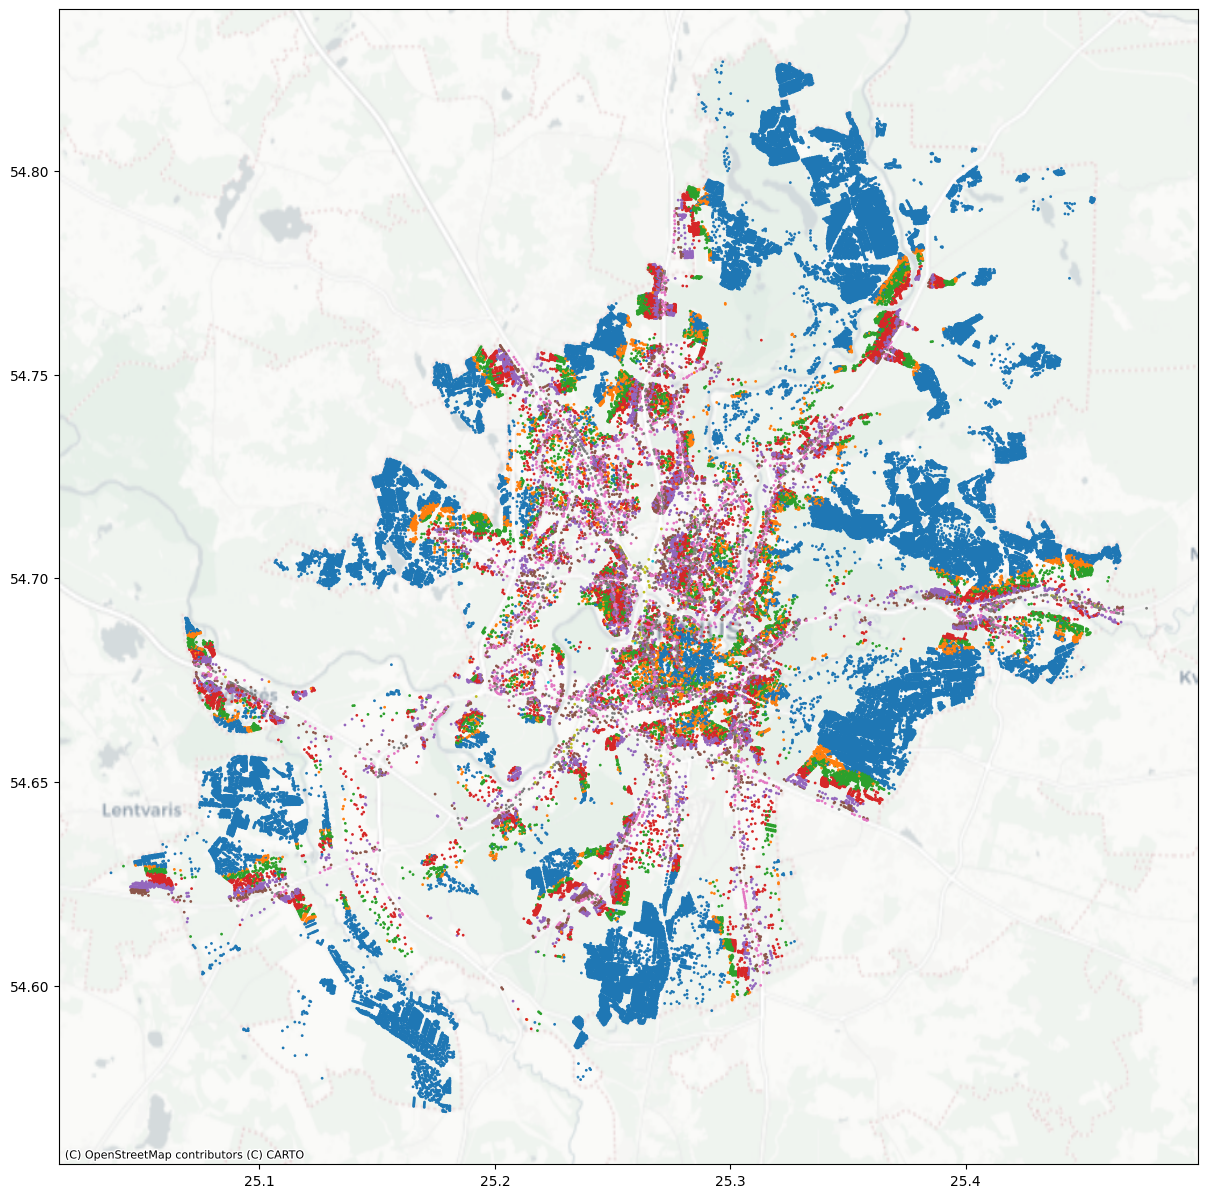

In [38]:
fig, ax = plt.subplots(1, 1, figsize=(15, 15))

addresses_geom.plot(ax=ax, column='traffic_noise', markersize=1)

cx.add_basemap(ax, crs=addresses_geom.crs, source=cx.providers.CartoDB.Positron)

### Airport noise

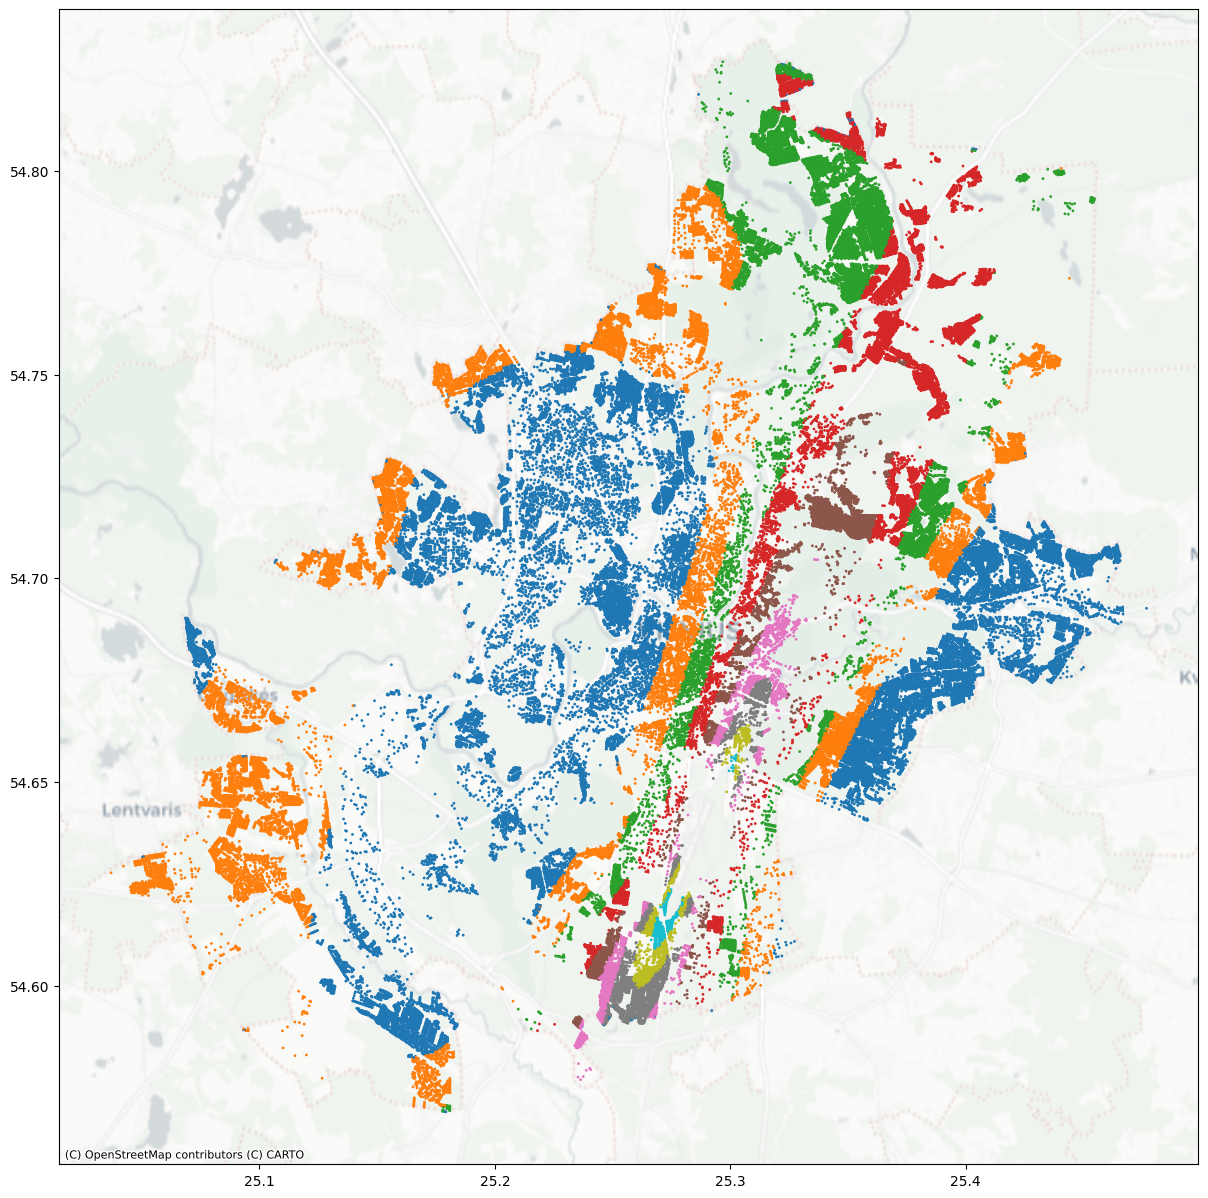

In [39]:
fig, ax = plt.subplots(1, 1, figsize=(15, 15))

addresses_geom.plot(ax=ax, column='airport_noise', markersize=1)

cx.add_basemap(ax, crs=addresses_geom.crs, source=cx.providers.CartoDB.Positron)

### Railway noise

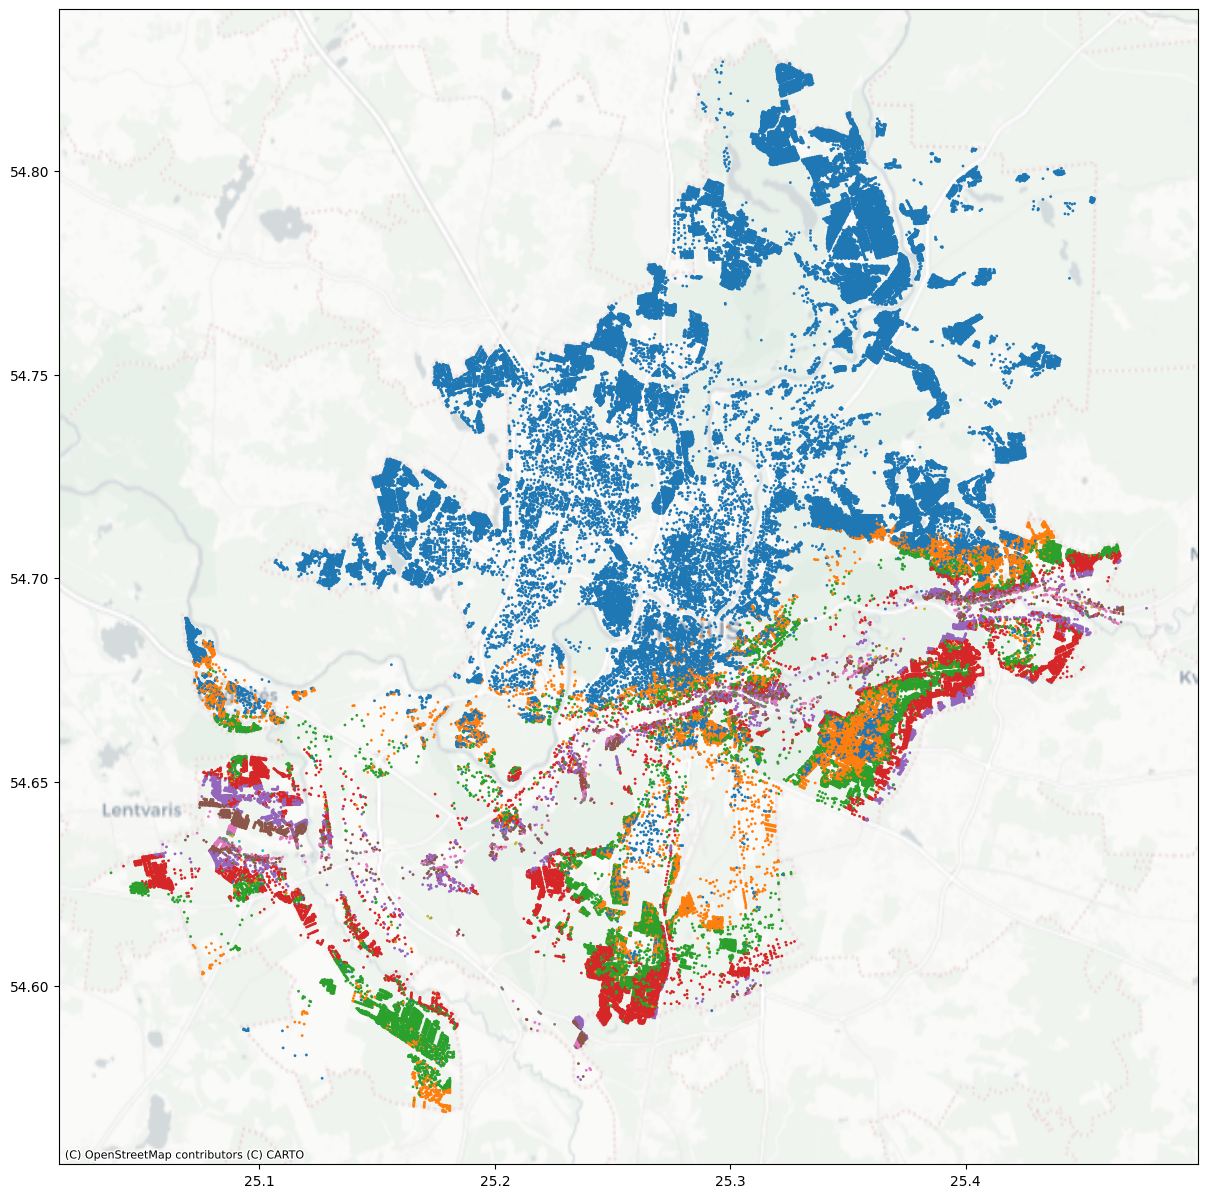

In [40]:
fig, ax = plt.subplots(1, 1, figsize=(15, 15))

addresses_geom.plot(ax=ax, column='railway_noise', markersize=1)

cx.add_basemap(ax, crs=addresses_geom.crs, source=cx.providers.CartoDB.Positron)

### Heating score

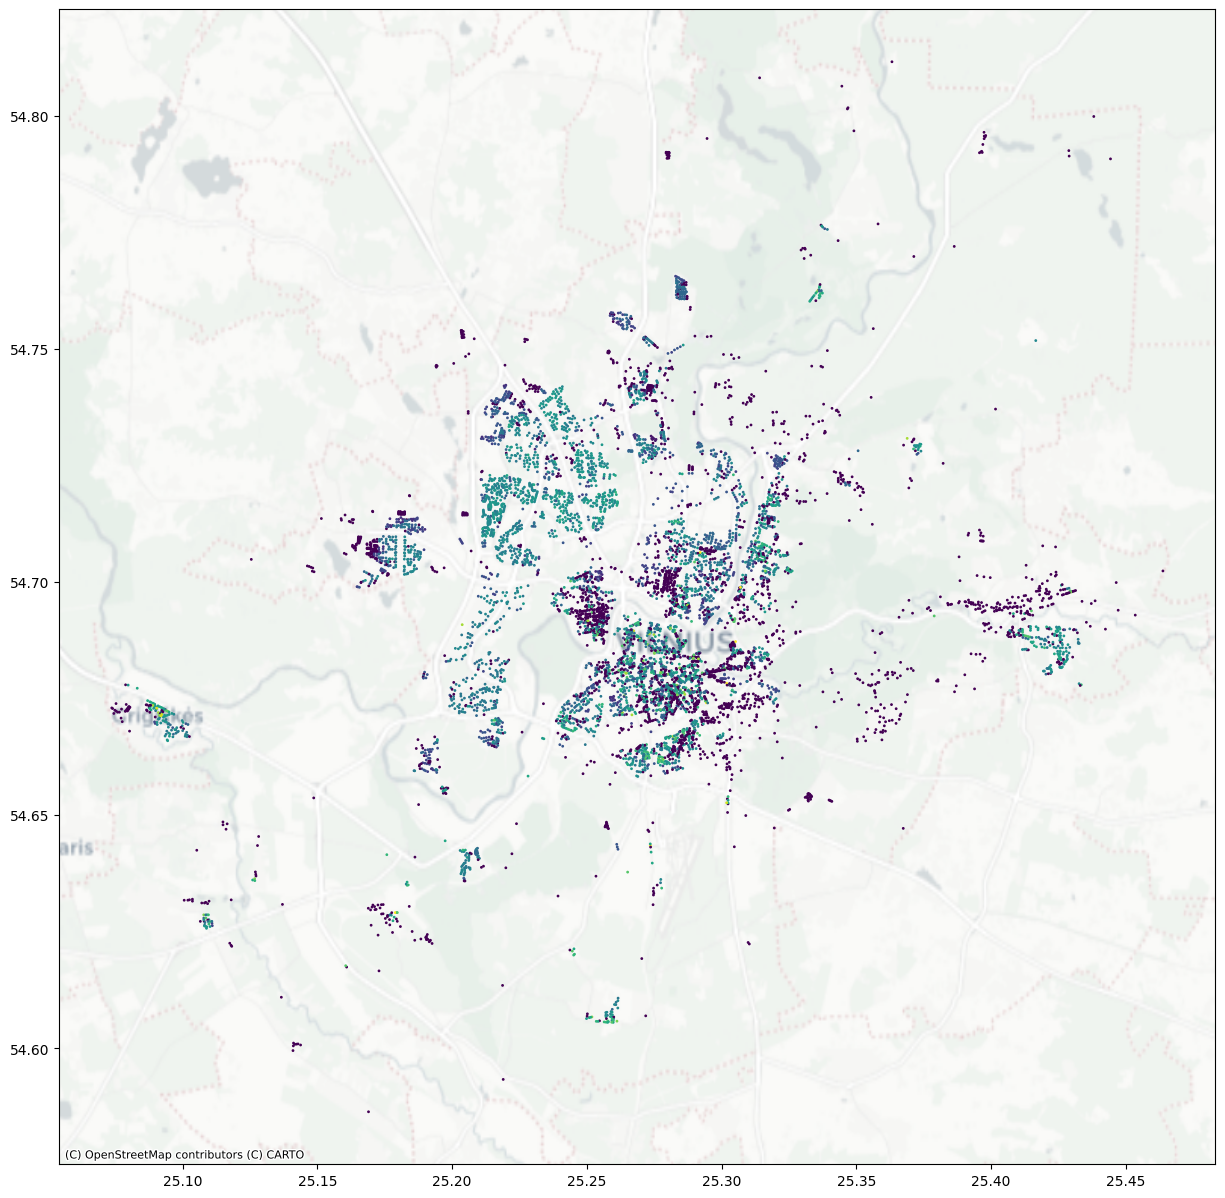

In [41]:
fig, ax = plt.subplots(1, 1, figsize=(15, 15))

addresses_geom.plot(ax=ax, column='heating_score', markersize=1)

cx.add_basemap(ax, crs=addresses_geom.crs, source=cx.providers.CartoDB.Positron)